In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#reading 4 daily datasets
gold_df = pd.read_csv('gold_data_daily_comprehensive_cleaned.csv')
bitcoin_df = pd.read_csv('Bitcoin_history_data.csv')
snp500_df = pd.read_csv('30_yr_market_data.csv')[['Date','S&P500']]
eth_df = pd.read_csv('ETH.csv')

In [3]:
#exploring dataset with daily gold prices
#take only part from 2015 till 2025
gold_df['Date'] = pd.to_datetime(gold_df['Date'])
gold_df_daily = gold_df[gold_df['Date'].dt.year.between(2016, 2025)]
gold_df_daily.tail() #five last observations

,DateTime,Date,Year,Month,Day,DayOfWeek,Quarter,Open,High,Low,Close,Volume,Price_Change,Price_Change_Percent,MA_7,MA_30,MA_90,MA_365,Volatility_30d,Source
6353,2025-12-24 00:00:00-05:00,2025-12-24,2025,12,24,Wednesday,4,4500.700195,4503.399902,4468.399902,4480.600098,500,-2.199707,-0.049070,4394.414272,4224.246663,3951.589988,3160.898078,0.950535,Yahoo Finance
6354,2025-12-26 00:00:00-05:00,2025-12-26,2025,12,26,Friday,4,4512.000000,4556.299805,4502.000000,4529.100098,263,48.500000,1.082444,4426.500000,4235.070003,3965.097767,3166.581092,0.879534,Yahoo Finance
6355,2025-12-29 00:00:00-05:00,2025-12-29,2025,12,29,Monday,4,4371.500000,4379.000000,4325.100098,4325.100098,2044,-204.000000,-4.504206,4423.300014,4239.676676,3976.005547,3171.713421,1.232489,Yahoo Finance
6356,2025-12-30 00:00:00-05:00,2025-12-30,2025,12,30,Tuesday,4,4346.399902,4403.600098,4338.000000,4370.100098,1837,45.000000,1.040438,4427.671456,4249.093343,3987.485550,3177.123284,1.149685,Yahoo Finance
6357,2025-12-31 00:00:00-05:00,2025-12-31,2025,12,31,Wednesday,4,4333.500000,4363.799805,4285.000000,4325.600098,785,-44.500000,-1.018283,4422.557199,4257.670011,3998.054441,3182.420819,1.165395,Yahoo Finance


In [4]:
#checking that overall numbers of NaN values is zero
print("Number of NaN values:", gold_df_daily.isnull().sum().sum())

Number of NaN values: 0


In [5]:
gold_df_daily.drop_duplicates(ignore_index=True) 
gold_df_daily.shape #number of rows and columns

(2513, 20)

In [6]:
gold_df_daily.describe()

,Date,Year,Month,Day,Quarter,Open,High,Low,Close,Volume,Price_Change,Price_Change_Percent,MA_7,MA_30,MA_90,MA_365,Volatility_30d
count,2513,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000,2513.000000
mean,2021-01-02 06:35:23.040190976,2020.504178,6.542380,15.726622,2.513729,1832.293036,1841.840947,1823.435456,1832.916950,5179.271787,1.299363,0.060652,1828.953094,1814.126904,1778.883734,1662.899105,0.912904
min,2016-01-04 00:00:00,2016.000000,1.000000,1.000000,1.000000,1063.400024,1081.500000,1063.199951,1073.900024,0.000000,-248.699951,-5.735171,1070.014282,1070.063338,1105.645557,1167.072327,0.432387
25%,2018-07-06 00:00:00,2018.000000,4.000000,8.000000,2.000000,1298.000000,1304.400024,1294.699951,1299.900024,53.000000,-6.699951,-0.408014,1297.014282,1297.170015,1291.222224,1272.059727,0.689921
50%,2021-01-04 00:00:00,2021.000000,7.000000,16.000000,3.000000,1760.800049,1767.900024,1750.500000,1758.000000,210.000000,1.000000,0.066911,1758.314296,1753.976664,1776.958889,1686.851230,0.864730
75%,2023-07-05 00:00:00,2023.000000,10.000000,23.000000,4.000000,1961.300049,1969.800049,1952.599976,1961.599976,652.000000,9.700195,0.581937,1959.128557,1941.896655,1929.611110,1845.900273,1.034294
max,2025-12-31 00:00:00,2025.000000,12.000000,31.000000,4.000000,4512.000000,4556.299805,4502.000000,4529.100098,386334.000000,146.500000,5.947668,4427.671456,4257.670011,3998.054441,3182.420819,2.648976
std,NaN,2.871325,3.425372,8.760508,1.114428,666.805696,672.697666,661.990109,667.873423,28545.573889,21.430794,0.968060,662.159248,641.227679,592.156807,451.041302,0.323454


In [7]:
#exploring dataset with daily Bitcoin prices
#take only part from 2015 till 2025
bitcoin_df['Date'] = pd.to_datetime(bitcoin_df['Date'])
bitcoin_df_daily = bitcoin_df[bitcoin_df['Date'].dt.year.between(2016, 2025)]
bitcoin_df_daily.head() #five last observations

,Date,Close,High,Low,Open,Volume
471,2016-01-01,434.334015,436.246002,427.515015,430.721008,36278900
472,2016-01-02,433.437988,436.062012,431.869995,434.622009,30096600
473,2016-01-03,430.010986,433.743011,424.705994,433.578003,39633800
474,2016-01-04,433.091003,434.516998,429.084015,430.061005,38477500
475,2016-01-05,431.959991,434.182007,429.675995,433.069000,34522600


In [8]:
#checking that overall numbers of NaN values is zero
print("Number of NaN values:", bitcoin_df_daily.isnull().sum().sum())

Number of NaN values: 0


In [9]:
bitcoin_df_daily.drop_duplicates(ignore_index=True) 
bitcoin_df_daily.shape #number of rows and columns

(3653, 6)

In [10]:
bitcoin_df_daily.describe()

,Date,Close,High,Low,Open,Volume
count,3653,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03
mean,2020-12-31 00:00:00,30272.254452,30858.827935,29606.180590,30249.572502,2.441560e+10
min,2016-01-01 00:00:00,364.330994,374.950012,354.914001,365.072998,2.851400e+07
25%,2018-07-02 00:00:00,6416.314941,6535.410156,6316.879883,6413.629883,5.302482e+09
50%,2020-12-31 00:00:00,17130.486328,17567.699219,16812.369141,17128.894531,2.049660e+10
75%,2023-07-02 00:00:00,46453.566406,47510.726562,45235.816406,46415.898438,3.557456e+10
max,2025-12-31 00:00:00,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11
std,NaN,32066.790421,32597.029482,31481.900581,32057.275563,2.287680e+10


In [11]:
#exploring dataset with daily S&P500 index
#take only part from 2015 till 2025
snp500_df['Date'] = pd.to_datetime(snp500_df['Date'])
snp500_df_daily = snp500_df[snp500_df['Date'].dt.year.between(2016, 2025)]
snp500_df_daily.tail() #five last observations

,Date,S&P500
9224,2025-12-26,6929.94
9225,2025-12-27,NaN
9226,2025-12-28,NaN
9227,2025-12-29,6905.74
9228,2025-12-30,6896.24


In [12]:
print("Number of NaN values:", snp500_df_daily.isnull().sum().sum())

Number of NaN values: 1139


In [13]:
#since number of S&P500 NaN values is the same as number of all days substracted 
#trading days in the considered period, we can just drop them, despite the fact that it is a significant number
snp500_df_daily = snp500_df_daily.dropna()


In [14]:
snp500_df_daily.drop_duplicates(ignore_index=True) 
snp500_df_daily.shape #number of rows and columns

(2513, 2)

In [15]:
snp500_df_daily.describe()

,Date,S&P500
count,2513,2513.000000
mean,2020-12-29 16:02:06.064464896,3769.197087
min,2016-01-04 00:00:00,1829.080000
25%,2018-07-02 00:00:00,2711.740000
50%,2020-12-29 00:00:00,3674.840000
75%,2023-06-29 00:00:00,4514.020000
max,2025-12-30 00:00:00,6932.050000
std,NaN,1291.438064


In [16]:
#exploring dataset with daily Ethereum prices
#take only part from 2015 till 2025
eth_df['Date'] = pd.to_datetime(eth_df['date'])
eth_df_daily = eth_df[eth_df['Date'].dt.year.between(2016, 2025)]
eth_df_daily.tail() #five last observations

,date,ticker,open,high,low,close,volume,Date
3794,2025-12-27,ETH,2925.745016,2957.300540,2917.271274,2947.998279,7.378783e+09,2025-12-27
3795,2025-12-28,ETH,2947.898258,2957.138760,2925.745408,2948.568037,9.227601e+09,2025-12-28
3796,2025-12-29,ETH,2948.559158,3051.941893,2908.748027,2934.538353,2.595769e+10,2025-12-29
3797,2025-12-30,ETH,2934.416247,3002.804601,2916.329968,2971.416672,1.881670e+10,2025-12-30
3798,2025-12-31,ETH,2971.407532,3021.849538,2959.143875,2967.037579,1.645189e+10,2025-12-31


In [17]:
#checking that overall numbers of NaN values is zero
print("Number of NaN values:", eth_df_daily.isnull().sum().sum())

Number of NaN values: 0


In [18]:
eth_df_daily.drop_duplicates(ignore_index=True) 
eth_df_daily.shape #number of rows and columns

(3653, 8)

In [19]:
eth_df_daily.describe()

,open,high,low,close,volume,Date
count,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03,3653
mean,1387.001824,1424.988315,1345.722216,1387.663691,1.219076e+10,2020-12-31 00:00:00
min,0.933712,0.954822,0.929835,0.937124,2.060620e+05,2016-01-01 00:00:00
25%,194.738917,201.269000,187.373993,194.868528,2.030320e+09,2018-07-02 00:00:00
50%,1073.794268,1142.395782,1034.500000,1086.519305,9.149380e+09,2020-12-31 00:00:00
75%,2441.580924,2523.171338,2367.833737,2448.921189,1.770563e+10,2023-07-02 00:00:00
max,4831.088203,4953.732914,4718.039256,4831.348723,9.773662e+10,2025-12-31 00:00:00
std,1325.859408,1360.587500,1287.819291,1325.746756,1.246486e+10,NaN


In [20]:
#create combined dataset of daily obervations of gold, Bitcoin, Ethereeum close price and value of S&P500 on a given day
snp500_for_merging = snp500_df_daily[['Date', 'S&P500']]
gold_for_merging = gold_df_daily[['Date', 'Close']]
bitcoin_for_merging = bitcoin_df_daily[['Date', 'Close']]
eth_for_merging = eth_df_daily[['Date', 'close']]

gold_for_merging.columns = ['Date', 'Gold_Close']
bitcoin_for_merging.columns = ['Date', 'Bitcoin_Close']
eth_for_merging.columns = ['Date', 'Ethereum_Close']

combined_df = (snp500_for_merging.set_index('Date')
               .join(gold_for_merging.set_index('Date'))
               .join(bitcoin_for_merging.set_index('Date'))
               .join(eth_for_merging.set_index('Date'))
               .dropna()
               .reset_index())

combined_df.insert(
    1,
    'DayOfWeek',
    pd.to_datetime(combined_df['Date']).dt.dayofweek + 1,
)

# combined_df.to_csv('combined_data_daily.csv', index=False)

In [21]:
combined_df

,Date,DayOfWeek,S&P500,Gold_Close,Bitcoin_Close,Ethereum_Close
0,2016-01-04,1,2012.66,1075.099976,433.091003,0.954480
1,2016-01-05,2,2016.71,1078.400024,431.959991,0.950176
2,2016-01-06,3,1990.26,1091.900024,429.105011,0.950860
3,2016-01-07,4,1943.09,1107.699951,458.048004,0.942005
4,2016-01-08,5,1922.03,1097.800049,453.230011,0.986789
...,...,...,...,...,...,...
2505,2025-12-23,2,6909.79,4482.799805,87414.000000,2963.374114
2506,2025-12-24,3,6932.05,4480.600098,87611.960938,2945.590470
2507,2025-12-26,5,6929.94,4529.100098,87301.429688,2925.745692
2508,2025-12-29,1,6905.74,4325.100098,87138.140625,2934.538353


In [22]:
#load data from the created csv file
df = pd.read_csv('combined_data_daily.csv', parse_dates=['Date'])
df_time = df.set_index('Date')
num_cols = ['S&P500', 'Gold_Close', 'Bitcoin_Close', 'Ethereum_Close']


In [23]:
#descriptive statictic for combined data
df.describe()

,Date,DayOfWeek,S&P500,Gold_Close,Bitcoin_Close,Ethereum_Close
count,2510,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000
mean,2020-12-31 07:24:02.868525824,3.025498,3770.840892,1830.987409,30269.179781,1387.866094
min,2016-01-04 00:00:00,1.000000,1829.080000,1073.900024,364.330994,0.942005
25%,2018-07-05 06:00:00,2.000000,2712.177500,1299.150024,6454.435181,197.087544
50%,2020-12-30 12:00:00,3.000000,3678.190000,1757.799988,17201.496094,1067.514761
75%,2023-06-29 18:00:00,4.000000,4514.057500,1960.275024,46367.790039,2439.009075
max,2025-12-30 00:00:00,5.000000,6932.050000,4529.100098,124752.531250,4831.348723
std,NaN,1.398965,1291.284554,665.524772,32065.527771,1326.287677


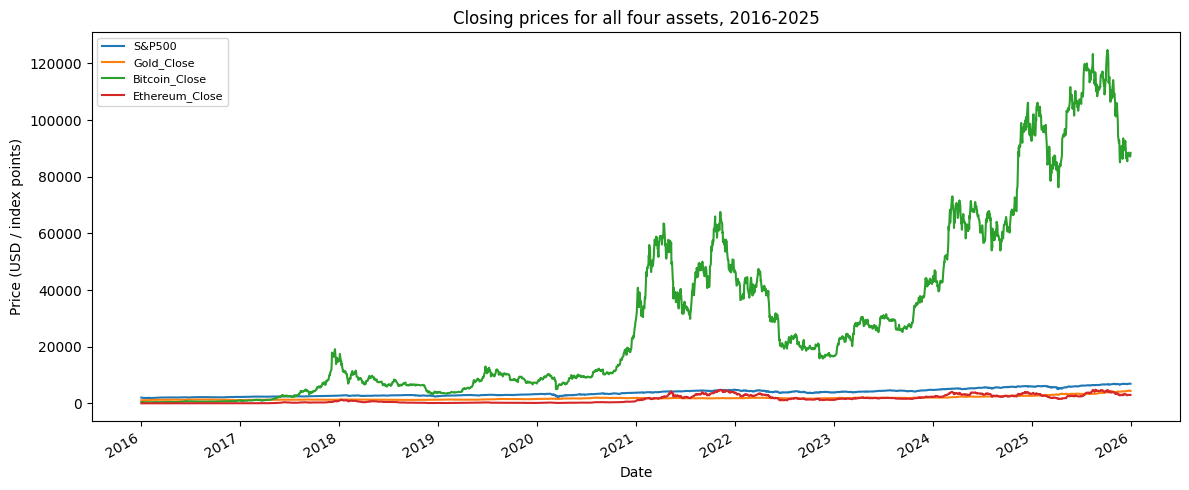

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
df_time[num_cols].plot(ax=ax)
ax.set_title('Closing prices for all four assets, 2016-2025')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD / index points)')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

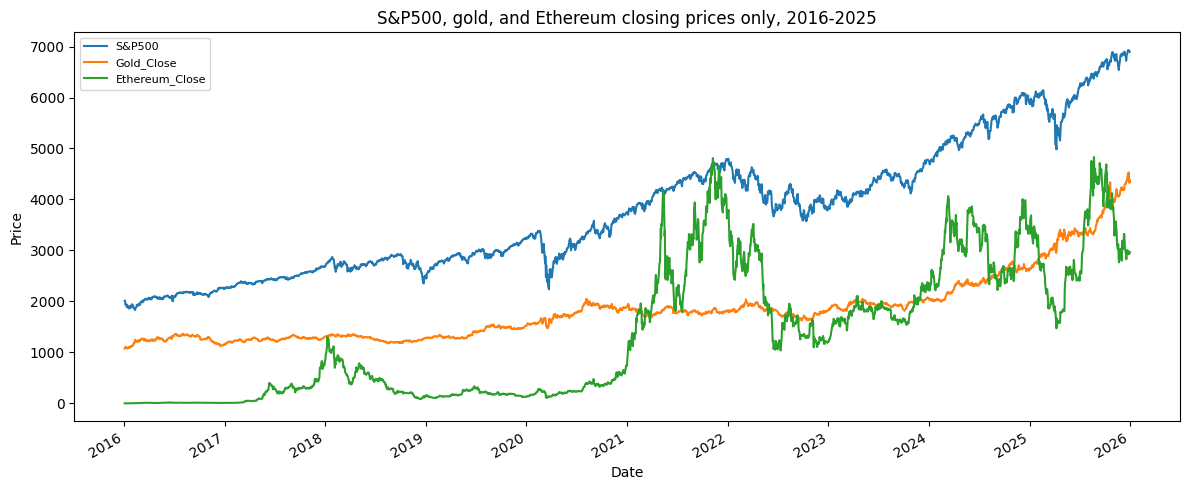

In [25]:
cols_without_btc = ['S&P500', 'Gold_Close', 'Ethereum_Close']
fig, ax = plt.subplots(figsize=(12, 5))
df_time[cols_without_btc].plot(ax=ax)
ax.set_title('S&P500, gold, and Ethereum closing prices only, 2016-2025')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
plt.show()

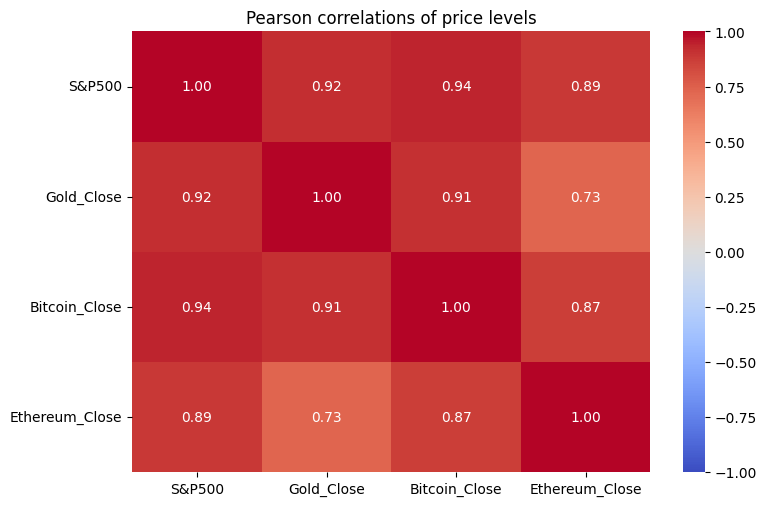

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    xticklabels=num_cols,
    yticklabels=num_cols,
    ax=ax,
    vmin=-1,
    vmax=1,
)
fig.tight_layout()
plt.title('Pearson correlations of price levels')
plt.show()

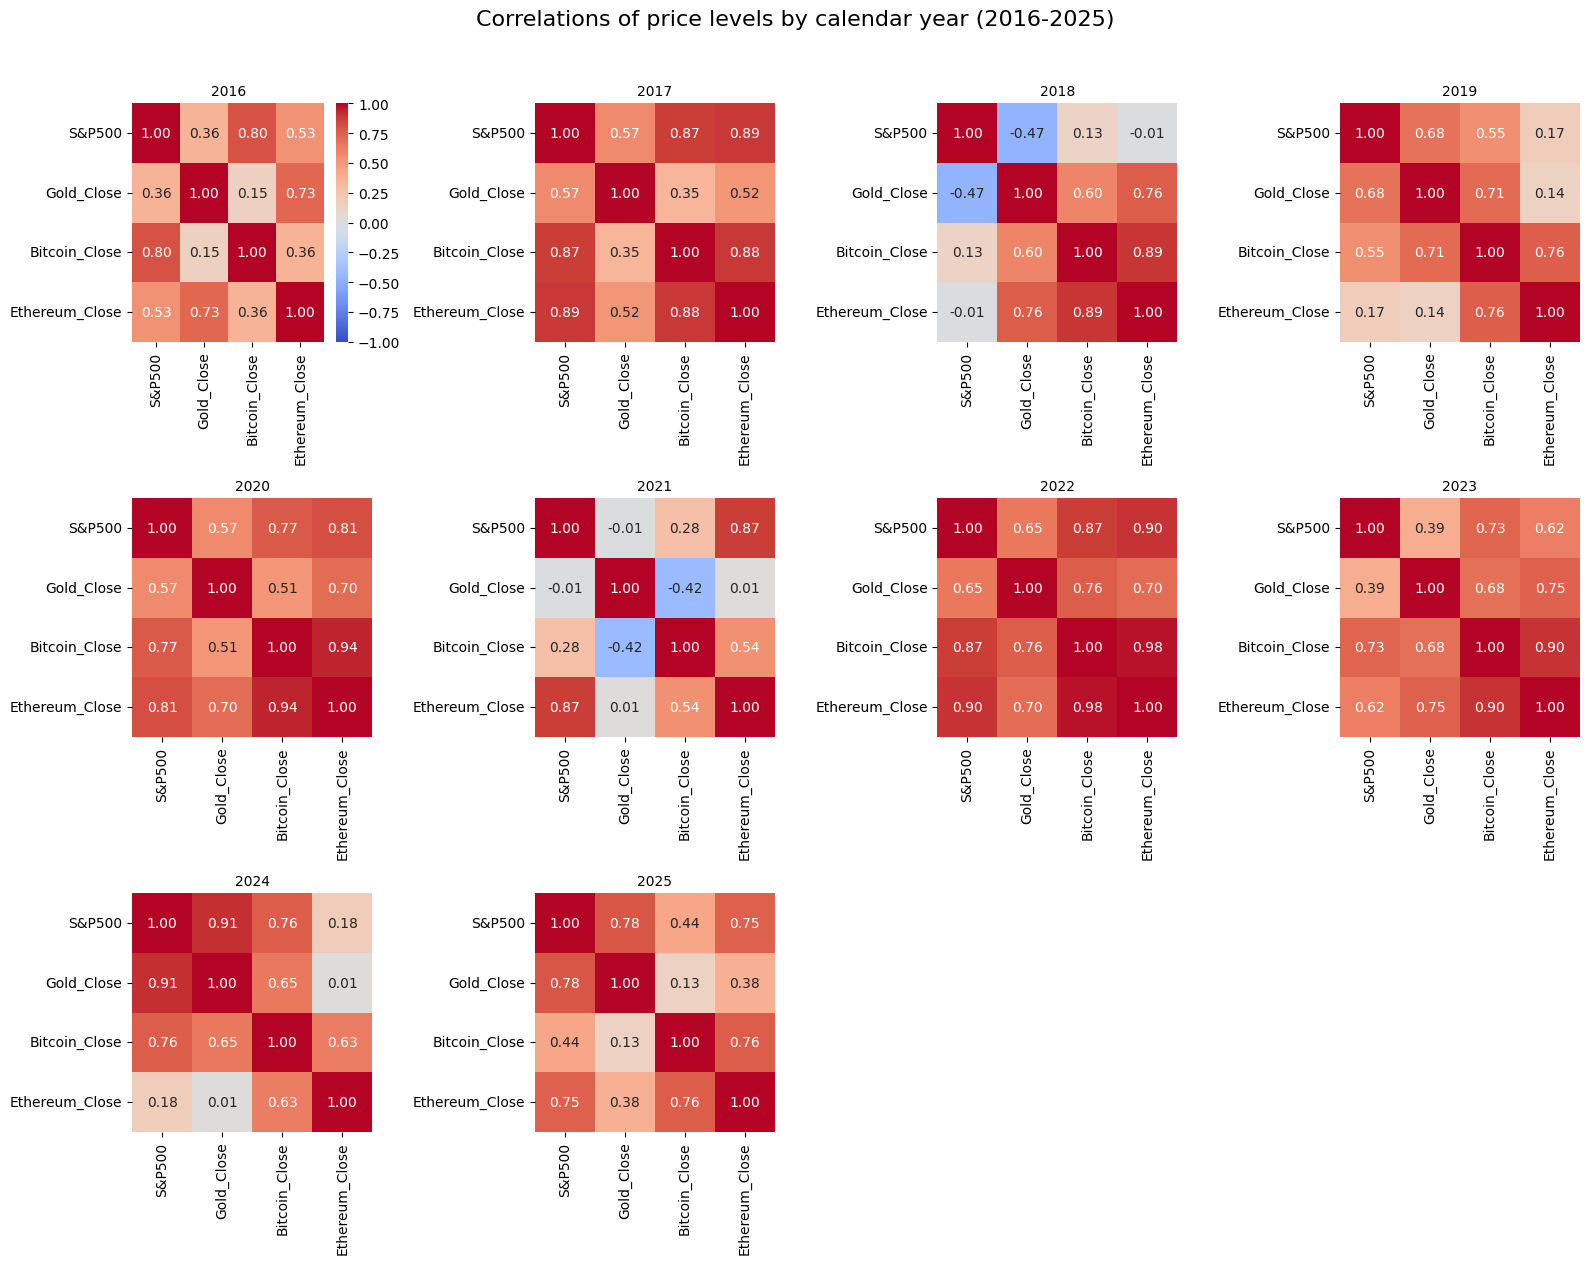

In [27]:
df = df.copy()
df['Year'] = df['Date'].dt.year
years = sorted(df['Year'].unique())

n_rows, n_cols = 3, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()
vmin, vmax = -1, 1

for idx, year in enumerate(years):
    if idx >= len(axes):
        break
    corr = df.loc[df['Year'] == year, num_cols].corr()
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        fmt='.2f',
        vmin=vmin,
        vmax=vmax,
        xticklabels=num_cols,
        yticklabels=num_cols,
        ax=axes[idx],
        cbar=idx == 0,
    )
    axes[idx].set_title(str(year), fontsize=10)

for j in range(len(years), len(axes)):
    axes[j].axis('off')

fig.tight_layout()
plt.suptitle('Correlations of price levels by calendar year (2016-2025)', fontsize=16, y=1.05)
plt.show()

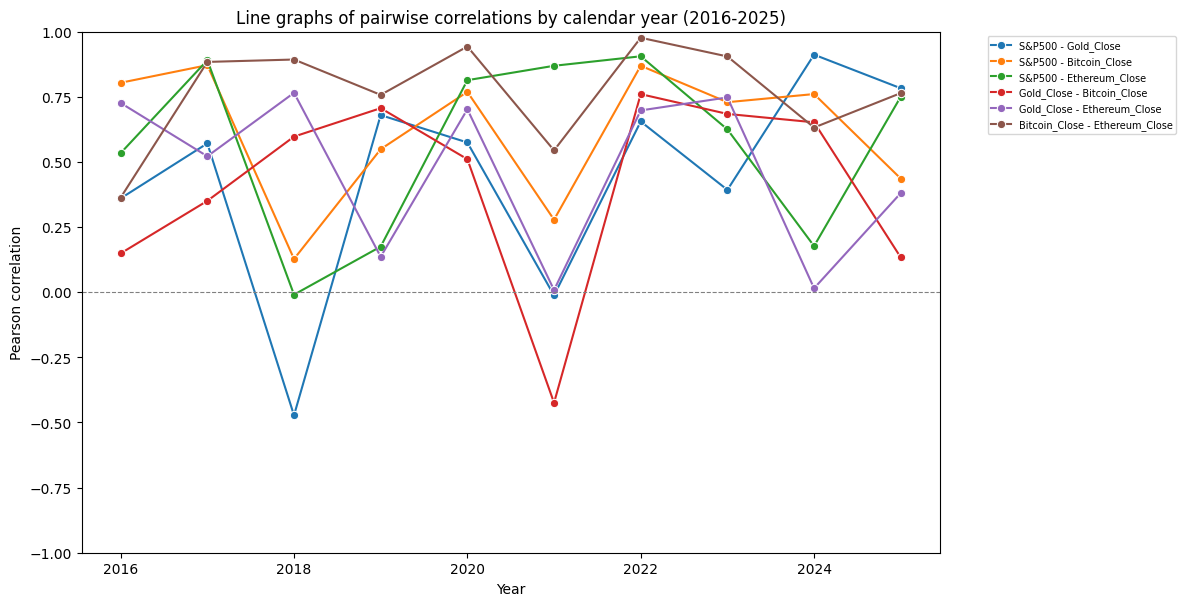

In [28]:
pairs = []
corr_values = []

for year in years:
    corr = df.loc[df['Year'] == year, num_cols].corr()
    for i, a1 in enumerate(num_cols):
        for j, a2 in enumerate(num_cols):
            if i < j:
                pairs.append(f'{a1} - {a2}')
                corr_values.append(corr.loc[a1, a2])

corr_df = pd.DataFrame({
    'Year': [y for y in years for _ in range(6)],
    'Pair': pairs,
    'Correlation': corr_values,
})

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=corr_df, x='Year', y='Correlation', hue='Pair', marker='o', ax=ax)
ax.set_ylim(-1, 1)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylabel('Pearson correlation')
ax.set_xlabel('Year')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
fig.tight_layout()
plt.title('Line graphs of pairwise correlations by calendar year (2016-2025)')
plt.show()

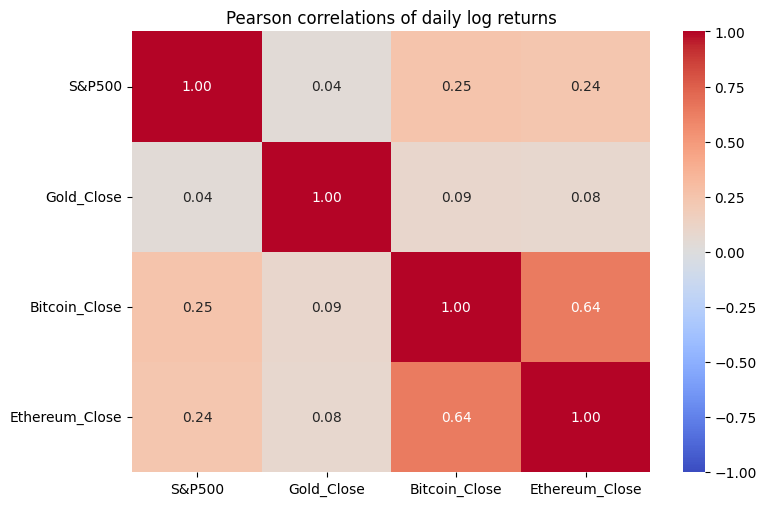

In [29]:
df_lr = df.loc[df['Date'].dt.year.between(2016, 2025), num_cols]
log_ret = np.log(df_lr).diff().dropna()
corr_log = log_ret.corr()

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    corr_log,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    xticklabels=num_cols,
    yticklabels=num_cols,
    ax=ax,
    vmin=-1,
    vmax=1,
)
fig.tight_layout()
plt.title('Pearson correlations of daily log returns')
plt.show()

### Hypothesis 1:

$H_0:$ for each of 6 pairs correlation of price level is no more than correlation of respective pair log-return

$H_1:$ correlation of price level is Higher than correlation of respective pair log-return

Correlation is computed as Person correlation.
Log returns: $r_{t} = \ln P_t - \ln P_{t-1}$ for each asset.

In [30]:
# closing prices vs daily log returns
from itertools import combinations
from IPython.display import display

short_names = ['S&P500', 'Gold', 'BTC', 'ETH']
prices_b1a = df[num_cols].dropna()
log_ret_b1a = np.log(prices_b1a).diff().dropna()
prices_b1a = prices_b1a.loc[log_ret_b1a.index]

corr_levels = prices_b1a.corr()
corr_logret = log_ret_b1a.corr()
delta_matrix = corr_levels - corr_logret

n_b1a = len(log_ret_b1a)
pair_indices = list(combinations(range(len(num_cols)), 2))

print('Pearson correlation — price levels')
display(corr_levels)
print('Pearson correlation — daily log returns')
display(corr_logret)
print('Difference (levels - log returns)')
display(delta_matrix.round(4))



Pearson correlation — price levels


,S&P500,Gold_Close,Bitcoin_Close,Ethereum_Close
S&P500,1.000000,0.919397,0.943753,0.889398
Gold_Close,0.919397,1.000000,0.912254,0.728039
Bitcoin_Close,0.943753,0.912254,1.000000,0.871172
Ethereum_Close,0.889398,0.728039,0.871172,1.000000


Pearson correlation — daily log returns


,S&P500,Gold_Close,Bitcoin_Close,Ethereum_Close
S&P500,1.000000,0.037533,0.253563,0.240260
Gold_Close,0.037533,1.000000,0.093414,0.083751
Bitcoin_Close,0.253563,0.093414,1.000000,0.640187
Ethereum_Close,0.240260,0.083751,0.640187,1.000000


Difference (levels - log returns)


,S&P500,Gold_Close,Bitcoin_Close,Ethereum_Close
S&P500,0.0000,0.8819,0.6902,0.6491
Gold_Close,0.8819,0.0000,0.8188,0.6443
Bitcoin_Close,0.6902,0.8188,0.0000,0.2310
Ethereum_Close,0.6491,0.6443,0.2310,0.0000


In [31]:
# bootstrap of correlation differences (levels minus log returns)
rng = np.random.default_rng(42)
B = 10_000

P = prices_b1a.to_numpy()
R = log_ret_b1a.to_numpy()
n_obs = P.shape[0]

def corr_two_cols(M, a, b):
    x, y = M[:, a], M[:, b]
    if np.std(x) <= 1e-15 or np.std(y) <= 1e-15:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

rows = []
alpha_pair = 0.05 / 6

for i, j in pair_indices:
    rho_l = corr_two_cols(P, i, j)
    rho_r = corr_two_cols(R, i, j)
    delta = rho_l - rho_r

    boot = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n_obs, size=n_obs)
        boot[b] = corr_two_cols(P[idx], i, j) - corr_two_cols(R[idx], i, j)

    p_one_sided = (1 + np.sum(boot <= 0)) / (B + 1)
    reject = p_one_sided < alpha_pair

    label = f'{short_names[i]} — {short_names[j]}'
    rows.append({
        'pair': label,
        'rho_levels': rho_l,
        'rho_log_ret': rho_r,
        'delta': delta,
        'p_one_sided': p_one_sided,
        'reject_H0_Bonferroni': reject,
    })

h1_results = pd.DataFrame(rows)
print(f'B = {B} bootstrap replications; Bonferroni alpha per pair = {alpha_pair:.5f}')
display(h1_results)



B = 10000 bootstrap replications; Bonferroni alpha per pair = 0.00833


,pair,rho_levels,rho_log_ret,delta,p_one_sided,reject_H0_Bonferroni
0,S&P500 — Gold,0.919397,0.037533,0.881864,0.0001,True
1,S&P500 — BTC,0.943753,0.253563,0.690190,0.0001,True
2,S&P500 — ETH,0.889398,0.240260,0.649138,0.0001,True
3,Gold — BTC,0.912254,0.093414,0.818839,0.0001,True
4,Gold — ETH,0.728039,0.083751,0.644288,0.0001,True
5,BTC — ETH,0.871172,0.640187,0.230985,0.0001,True


$H_0$ is rejected for all 6 pairs

In [32]:
# BTC panel 2016–2025: date, weekday (Mon=1, ..., Sun=7)
btc_raw = pd.read_csv('Bitcoin_history_data.csv', parse_dates=['Date'])
btc_daily = btc_raw.loc[btc_raw['Date'].dt.year.between(2016, 2025), ['Date', 'Close']].copy()
btc_daily['DayOfWeek'] = btc_daily['Date'].dt.dayofweek + 1

# Daily return
btc_daily['BTC_daily_return'] = btc_daily['Close'].pct_change()
btc_daily = btc_daily.dropna(subset=['BTC_daily_return']).reset_index(drop=True)

df_btc_2016_2025 = btc_daily[['Date', 'DayOfWeek', 'BTC_daily_return']].copy()
df_btc_2016_2025['BTC_return_sign'] = np.where(
    df_btc_2016_2025['BTC_daily_return'] < 0, -1, 1
)
df_btc_2016_2025

,Date,DayOfWeek,BTC_daily_return,BTC_return_sign
0,2016-01-02,6,-0.002063,-1
1,2016-01-03,7,-0.007907,-1
2,2016-01-04,1,0.007163,1
3,2016-01-05,2,-0.002611,-1
4,2016-01-06,3,-0.006609,-1
...,...,...,...,...
3647,2025-12-27,6,0.005736,1
3648,2025-12-28,7,0.000384,1
3649,2025-12-29,1,-0.007943,-1
3650,2025-12-30,2,0.014827,1


In [33]:
# Proportion of BTC_return_sign == 1 by DayOfWeek
df_btc_with_up = df_btc_2016_2025.assign(is_up=df_btc_2016_2025['BTC_return_sign'] == 1)
btc_prop_by_dow = df_btc_with_up.groupby('DayOfWeek', sort=True).agg(
    n_obs=('is_up', 'size'),
    prop_sign_1=('is_up', 'mean'),
)

btc_prop_by_dow['prop_sign_1'] = btc_prop_by_dow['prop_sign_1'].round(4)
btc_prop_by_dow

,n_obs,prop_sign_1
DayOfWeek,,
1,522,0.5345
2,522,0.5115
3,522,0.5364
4,521,0.4933
5,521,0.5355
6,522,0.5632
7,522,0.5249


### Hypothesis 2

$H_0:$ share of days with positive return on Saturday on BTC is equal to $1/2$.

$H_1:$ share is not equal to $1/2$

In [34]:
# Two-sided binomial test for share of positive returns on Saturdays (DayOfWeek == 6), alpha = 5%
from scipy.stats import binomtest

btc_sat_sign = df_btc_2016_2025.loc[df_btc_2016_2025['DayOfWeek'] == 6, 'BTC_return_sign']
n_sat = len(btc_sat_sign)
k_pos = int((btc_sat_sign == 1).sum())
phat = k_pos / n_sat

binom_test_sat = binomtest(k_pos, n_sat, p=0.5, alternative='two-sided')
p_val = binom_test_sat.pvalue

print('DayOfWeek 6 (Saturday): n =', n_sat, ', n_positive =', k_pos, ', sample share =', round(phat, 4))
print('Two-sided binomial test H0: p = 0.5  =>  p-value =', round(p_val, 6))
print('Reject H0 at 5%:', p_val < 0.05)



DayOfWeek 6 (Saturday): n = 522 , n_positive = 294 , sample share = 0.5632
Two-sided binomial test H0: p = 0.5  =>  p-value = 0.004397
Reject H0 at 5%: True


### Preparing data for ML

In [35]:
combined_df = pd.read_csv('combined_data_daily.csv', parse_dates=['Date'])
combined_df.head(n=10)

,Date,DayOfWeek,S&P500,Gold_Close,Bitcoin_Close,Ethereum_Close
0,2016-01-04,1,2012.66,1075.099976,433.091003,0.954480
1,2016-01-05,2,2016.71,1078.400024,431.959991,0.950176
2,2016-01-06,3,1990.26,1091.900024,429.105011,0.950860
3,2016-01-07,4,1943.09,1107.699951,458.048004,0.942005
4,2016-01-08,5,1922.03,1097.800049,453.230011,0.986789
5,2016-01-11,1,1923.67,1096.500000,448.428009,1.061600
6,2016-01-12,2,1938.68,1085.599976,435.690002,1.141000
7,2016-01-13,3,1890.28,1087.500000,432.371002,1.125200
8,2016-01-14,4,1921.84,1073.900024,430.306000,1.189590
9,2016-01-15,5,1880.33,1091.500000,364.330994,1.208010


In [36]:
# Log returns and return sign (+1 / -1) for each of the four price columns
combined_df = combined_df.rename(columns={
    'Gold_Close': 'Gold',
    'Bitcoin_Close': 'Bitcoin',
    'Ethereum_Close': 'Ethereum',
})

price_cols = ['S&P500', 'Gold', 'Bitcoin', 'Ethereum']
out_names = {
    'S&P500': 'sp500',
    'Gold': 'gold',
    'Bitcoin': 'btc',
    'Ethereum': 'eth',
}

for col, key in out_names.items():
    lr = np.log(combined_df[col]).diff()
    combined_df[f'{key}_log_return'] = lr
    # 1 if log return >= 0, -1 if < 0
    combined_df[f'{key}_return_sign'] = np.where(
        lr.isna(),
        np.nan,
        np.where(lr > 0, 1, np.where(lr < 0, -1, 1)),
    )

combined_df = combined_df.dropna().reset_index(drop=True)



log_return_cols = ['sp500_log_return', 'gold_log_return', 'btc_log_return', 'eth_log_return']
combined_df['sum_log_return'] = combined_df[log_return_cols].sum(axis=1)
combined_df['weighted_log_return'] = combined_df['sum_log_return'] * combined_df['DayOfWeek']

sign_cols = ['sp500_return_sign', 'gold_return_sign', 'btc_return_sign', 'eth_return_sign']
combined_df['total_trend'] = combined_df[sign_cols].sum(axis=1) / 2

combined_df.head(10)

,Date,DayOfWeek,S&P500,Gold,Bitcoin,Ethereum,sp500_log_return,sp500_return_sign,gold_log_return,gold_return_sign,btc_log_return,btc_return_sign,eth_log_return,eth_return_sign,sum_log_return,weighted_log_return,total_trend
0,2016-01-05,2,2016.71,1078.400024,431.959991,0.950176,0.002010,1.0,0.003065,1.0,-0.002615,-1.0,-0.004519,-1.0,-0.002059,-0.004119,0.0
1,2016-01-06,3,1990.26,1091.900024,429.105011,0.950860,-0.013202,-1.0,0.012441,1.0,-0.006631,-1.0,0.000720,1.0,-0.006673,-0.020019,0.0
2,2016-01-07,4,1943.09,1107.699951,458.048004,0.942005,-0.023986,-1.0,0.014366,1.0,0.065272,1.0,-0.009356,-1.0,0.046297,0.185187,0.0
3,2016-01-08,5,1922.03,1097.800049,453.230011,0.986789,-0.010898,-1.0,-0.008978,-1.0,-0.010574,-1.0,0.046446,1.0,0.015996,0.079982,-1.0
4,2016-01-11,1,1923.67,1096.500000,448.428009,1.061600,0.000853,1.0,-0.001185,-1.0,-0.010652,-1.0,0.073076,1.0,0.062093,0.062093,0.0
5,2016-01-12,2,1938.68,1085.599976,435.690002,1.141000,0.007773,1.0,-0.009990,-1.0,-0.028817,-1.0,0.072128,1.0,0.041093,0.082186,0.0
6,2016-01-13,3,1890.28,1087.500000,432.371002,1.125200,-0.025282,-1.0,0.001749,1.0,-0.007647,-1.0,-0.013944,-1.0,-0.045125,-0.135375,-1.0
7,2016-01-14,4,1921.84,1073.900024,430.306000,1.189590,0.016558,1.0,-0.012585,-1.0,-0.004787,-1.0,0.055648,1.0,0.054834,0.219336,0.0
8,2016-01-15,5,1880.33,1091.500000,364.330994,1.208010,-0.021836,-1.0,0.016256,1.0,-0.166434,-1.0,0.015366,1.0,-0.156648,-0.783240,0.0
9,2016-01-19,2,1881.33,1089.900024,380.148987,1.371390,0.000532,1.0,-0.001467,-1.0,0.042500,1.0,0.126850,1.0,0.168416,0.336831,1.0


In [37]:
# add ISO-based week number
iso = combined_df['Date'].dt.isocalendar()
iso_week_start = combined_df['Date'] - pd.to_timedelta(iso['day'] - 1, unit='D')
week_number = pd.factorize(iso_week_start, sort=True)[0] + 1

if 'Week number' in combined_df.columns:
    combined_df = combined_df.drop(columns=['Week number'])

date_pos = combined_df.columns.get_loc('Date')
combined_df.insert(date_pos + 1, 'Week number', week_number.astype(int))

combined_df.head(10)

,Date,Week number,DayOfWeek,S&P500,Gold,Bitcoin,Ethereum,sp500_log_return,sp500_return_sign,gold_log_return,gold_return_sign,btc_log_return,btc_return_sign,eth_log_return,eth_return_sign,sum_log_return,weighted_log_return,total_trend
0,2016-01-05,1,2,2016.71,1078.400024,431.959991,0.950176,0.002010,1.0,0.003065,1.0,-0.002615,-1.0,-0.004519,-1.0,-0.002059,-0.004119,0.0
1,2016-01-06,1,3,1990.26,1091.900024,429.105011,0.950860,-0.013202,-1.0,0.012441,1.0,-0.006631,-1.0,0.000720,1.0,-0.006673,-0.020019,0.0
2,2016-01-07,1,4,1943.09,1107.699951,458.048004,0.942005,-0.023986,-1.0,0.014366,1.0,0.065272,1.0,-0.009356,-1.0,0.046297,0.185187,0.0
3,2016-01-08,1,5,1922.03,1097.800049,453.230011,0.986789,-0.010898,-1.0,-0.008978,-1.0,-0.010574,-1.0,0.046446,1.0,0.015996,0.079982,-1.0
4,2016-01-11,2,1,1923.67,1096.500000,448.428009,1.061600,0.000853,1.0,-0.001185,-1.0,-0.010652,-1.0,0.073076,1.0,0.062093,0.062093,0.0
5,2016-01-12,2,2,1938.68,1085.599976,435.690002,1.141000,0.007773,1.0,-0.009990,-1.0,-0.028817,-1.0,0.072128,1.0,0.041093,0.082186,0.0
6,2016-01-13,2,3,1890.28,1087.500000,432.371002,1.125200,-0.025282,-1.0,0.001749,1.0,-0.007647,-1.0,-0.013944,-1.0,-0.045125,-0.135375,-1.0
7,2016-01-14,2,4,1921.84,1073.900024,430.306000,1.189590,0.016558,1.0,-0.012585,-1.0,-0.004787,-1.0,0.055648,1.0,0.054834,0.219336,0.0
8,2016-01-15,2,5,1880.33,1091.500000,364.330994,1.208010,-0.021836,-1.0,0.016256,1.0,-0.166434,-1.0,0.015366,1.0,-0.156648,-0.783240,0.0
9,2016-01-19,3,2,1881.33,1089.900024,380.148987,1.371390,0.000532,1.0,-0.001467,-1.0,0.042500,1.0,0.126850,1.0,0.168416,0.336831,1.0


In [38]:
combined_df.describe()

,Date,Week number,DayOfWeek,S&P500,Gold,Bitcoin,Ethereum,sp500_log_return,sp500_return_sign,gold_log_return,gold_return_sign,btc_log_return,btc_return_sign,eth_log_return,eth_return_sign,sum_log_return,weighted_log_return,total_trend
count,2509,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000,2509.000000
mean,2021-01-01 00:50:30.370665728,261.286967,3.026305,3771.541642,1831.288679,30281.071406,1388.418869,0.000491,0.096851,0.000559,0.085692,0.002120,0.060183,0.003206,0.016341,0.006376,0.013707,0.129534
min,2016-01-05 00:00:00,1.000000,1.000000,1829.080000,1073.900024,364.330994,0.942005,-0.127652,-1.000000,-0.059062,-1.000000,-0.464730,-1.000000,-0.550732,-1.000000,-1.147663,-4.590650,-2.000000
25%,2018-07-06 00:00:00,131.000000,2.000000,2712.920000,1299.900024,6456.580078,197.113177,-0.003616,-1.000000,-0.004088,-1.000000,-0.015386,-1.000000,-0.024349,-1.000000,-0.038860,-0.104900,-1.000000
50%,2020-12-31 00:00:00,261.000000,3.000000,3678.430000,1757.900024,17206.437500,1067.730721,0.000758,1.000000,0.000669,1.000000,0.001917,1.000000,0.000438,1.000000,0.005608,0.013210,0.000000
75%,2023-06-30 00:00:00,391.000000,4.000000,4514.070000,1960.300049,46368.585938,2439.840940,0.005786,1.000000,0.005796,1.000000,0.020437,1.000000,0.028744,1.000000,0.053464,0.143152,1.000000
max,2025-12-30 00:00:00,522.000000,5.000000,6932.050000,4529.100098,124752.531250,4831.348723,0.090895,1.000000,0.057775,1.000000,0.225119,1.000000,0.509687,1.000000,0.525950,1.744045,2.000000
std,NaN,150.397871,1.398658,1291.064526,665.486227,32066.383582,1326.262837,0.011460,0.995497,0.009690,0.996520,0.042257,0.998386,0.062122,1.000066,0.100023,0.306600,1.214759


In [39]:
print("Number of NaN values:", combined_df.isna().sum().sum())

Number of NaN values: 0


In [40]:
# Weekly aggregated dataframe
weekly_features = (
    combined_df
    .groupby('Week number', as_index=False)
    .agg({
        # Sum of log returns by asset
        'sp500_log_return': 'sum',
        'gold_log_return': 'sum',
        'btc_log_return': 'sum',
        'eth_log_return': 'sum',
        # Sum of return signs by asset
        'sp500_return_sign': 'sum',
        'gold_return_sign': 'sum',
        'btc_return_sign': 'sum',
        'eth_return_sign': 'sum',
        # Weekly sums of derived metrics
        'sum_log_return': 'sum',
        'weighted_log_return': 'sum',
        'total_trend': 'sum',
    })
)

week_key = (
    pd.DataFrame({
        'Week number': combined_df['Week number'].astype(int),
        'iso_week_start': iso_week_start,
    })
    .drop_duplicates('Week number')
)

weekly_features.head(10)

,Week number,sp500_log_return,gold_log_return,btc_log_return,eth_log_return,sp500_return_sign,gold_return_sign,btc_return_sign,eth_return_sign,sum_log_return,weighted_log_return,total_trend
0,1,-0.046075,0.020895,0.045452,0.033290,-2.0,2.0,-2.0,0.0,0.053561,0.241031,-1.0
1,2,-0.021935,-0.005755,-0.218337,0.202273,1.0,-1.0,-5.0,3.0,-0.043754,-0.555000,-1.0
2,3,0.014032,0.005209,0.048645,0.217337,2.0,-2.0,0.0,2.0,0.285222,0.503310,1.0
3,4,0.017333,0.017348,-0.007922,0.507961,1.0,1.0,1.0,1.0,0.534720,0.660898,2.0
4,5,-0.031513,0.036412,0.018473,0.017494,-1.0,3.0,-1.0,1.0,0.040865,0.299361,1.0
5,6,-0.008155,0.067864,-0.005931,0.781487,-3.0,1.0,1.0,3.0,0.835264,2.054946,1.0
6,7,0.028025,-0.007046,0.090795,-0.157662,0.0,2.0,2.0,0.0,-0.045888,0.391433,2.0
7,8,0.015661,-0.008652,0.026655,0.223027,1.0,-1.0,1.0,-1.0,0.256690,0.332905,0.0
8,9,0.026313,0.040251,-0.050333,0.563764,3.0,3.0,-3.0,5.0,0.579996,1.674012,4.0
9,10,0.011039,-0.008859,0.025826,0.063012,3.0,-3.0,3.0,-1.0,0.091018,0.379461,1.0


In [41]:
weekly_features.describe() 

,Week number,sp500_log_return,gold_log_return,btc_log_return,eth_log_return,sp500_return_sign,gold_return_sign,btc_return_sign,eth_return_sign,sum_log_return,weighted_log_return,total_trend
count,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000,522.000000
mean,261.500000,0.002359,0.002687,0.010190,0.015409,0.465517,0.411877,0.289272,0.078544,0.030644,0.065884,0.622605
std,150.832689,0.023845,0.020489,0.093269,0.139098,2.136368,2.065365,2.147766,2.165769,0.218820,0.638042,2.606891
min,1.000000,-0.162279,-0.097425,-0.494484,-0.603356,-5.000000,-5.000000,-5.000000,-5.000000,-1.287300,-3.582592,-9.000000
25%,131.250000,-0.008318,-0.008140,-0.029878,-0.058235,-1.000000,-1.000000,-1.000000,-1.000000,-0.079215,-0.243042,-1.000000
50%,261.500000,0.003942,0.003276,0.007017,0.004572,1.000000,1.000000,1.000000,0.000000,0.022094,0.044014,1.000000
75%,391.750000,0.015103,0.014401,0.057561,0.077789,2.000000,2.000000,1.000000,1.000000,0.165599,0.462423,2.000000
max,522.000000,0.114237,0.090090,0.411883,0.884704,5.000000,5.000000,5.000000,5.000000,0.896153,2.332987,8.000000


In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import xgboost as xgb

### target: Fri-to-Sat BTC return sign

In [43]:
btc = pd.read_csv('Bitcoin_history_data.csv', parse_dates=['Date'])
iso_btc = btc['Date'].dt.isocalendar()
btc['iso_week_start'] = btc['Date'] - pd.to_timedelta(iso_btc['day'] - 1, unit='D')
btc['weekday'] = btc['Date'].dt.weekday

fri_close = (
    btc[btc['weekday'] == 4][['iso_week_start', 'Date', 'Close']]
    .rename(columns={'Date': 'friday_date', 'Close': 'fri_close'})
)

sat_close = (
    btc[btc['weekday'] == 5][['iso_week_start', 'Date', 'Close']]
    .rename(columns={'Date': 'saturday_date', 'Close': 'sat_close'})
)

btc_fri_sat = fri_close.merge(sat_close, on='iso_week_start', how='inner')

btc_fri_sat['log_return_fri_to_sat'] = (
    np.log(btc_fri_sat['sat_close']) - np.log(btc_fri_sat['fri_close'])
)
TARGET_COL = 'BTC fri to sat close sign'
btc_fri_sat[TARGET_COL] = np.where(btc_fri_sat['log_return_fri_to_sat'] < 0, -1, 1)

print(f'Target rows: {len(btc_fri_sat)} | share +1: {(btc_fri_sat[TARGET_COL] == 1).mean():.3f}')
btc_fri_sat[
    ['iso_week_start', 'friday_date', 'saturday_date', 'fri_close', 'sat_close', TARGET_COL]
].head(6)

Target rows: 594 | share +1: 0.549


,iso_week_start,friday_date,saturday_date,fri_close,sat_close,BTC fri to sat close sign
0,2014-09-15,2014-09-19,2014-09-20,394.795990,408.903992,1
1,2014-09-22,2014-09-26,2014-09-27,404.424988,399.519989,-1
2,2014-09-29,2014-10-03,2014-10-04,359.511993,328.865997,-1
3,2014-10-06,2014-10-10,2014-10-11,361.562012,362.299011,1
4,2014-10-13,2014-10-17,2014-10-18,383.757996,391.441986,1
5,2014-10-20,2014-10-24,2014-10-25,358.345001,347.270996,-1


In [44]:
weekly_df_ml = (
    weekly_features
    .merge(week_key, on='Week number', how='left')
    .merge(
        btc_fri_sat[
            ['iso_week_start', TARGET_COL, 'friday_date', 'saturday_date',
             'fri_close', 'sat_close', 'log_return_fri_to_sat']
        ],
        on='iso_week_start',
        how='inner',
    )
    .drop(columns=['iso_week_start'])
    .sort_values('Week number')
    .reset_index(drop=True)
)

weekly_df_ml['prev_target'] = weekly_df_ml[TARGET_COL].shift(1)
weekly_df_ml = weekly_df_ml.dropna(subset=['prev_target']).reset_index(drop=True)
weekly_df_ml['prev_target'] = weekly_df_ml['prev_target'].astype(int)

FEATURE_COLS = [
    c for c in weekly_df_ml.columns
    if c not in [
        'Week number', TARGET_COL, 'friday_date', 'saturday_date',
        'fri_close', 'sat_close', 'log_return_fri_to_sat',
    ]
]

print(f'ML rows: {len(weekly_df_ml)} | features: {len(FEATURE_COLS)}')
weekly_df_ml[['Week number', 'friday_date', TARGET_COL, 'prev_target'] + FEATURE_COLS[:3]].tail(10)


ML rows: 521 | features: 12


,Week number,friday_date,BTC fri to sat close sign,prev_target,sp500_log_return,gold_log_return,btc_log_return
511,513,2025-10-31,1,1,0.007117,-0.033630,-0.013398
512,514,2025-11-07,-1,1,-0.016420,0.004310,-0.058099
513,515,2025-11-14,1,-1,0.000789,0.021814,-0.090820
514,516,2025-11-21,-1,1,-0.019663,-0.002670,-0.103800
515,517,2025-11-28,-1,-1,0.036593,0.034144,0.066254
516,518,2025-12-05,-1,-1,0.003107,-0.001281,-0.016988
517,519,2025-12-12,1,-1,-0.006277,0.020487,0.009826
518,520,2025-12-19,1,1,0.001038,0.014155,-0.024299
519,521,2025-12-26,1,1,0.013868,0.037730,-0.009144
520,522,2026-01-02,1,1,-0.004875,-0.035737,0.012846


### splitting train/val/test

In [45]:
n = len(weekly_df_ml)
train_end = int(np.floor(n * 0.85))
val_end = int(np.floor(n * 0.95))

train_df = weekly_df_ml.iloc[:train_end]
val_df = weekly_df_ml.iloc[train_end:val_end]
test_df = weekly_df_ml.iloc[val_end:]

X_train, X_val, X_test = train_df[FEATURE_COLS], val_df[FEATURE_COLS], test_df[FEATURE_COLS]
y_train = (train_df[TARGET_COL] == 1).astype(int)
y_val = (val_df[TARGET_COL] == 1).astype(int)
y_test = (test_df[TARGET_COL] == 1).astype(int)

THR_GRID = np.arange(0.30, 0.71, 0.01)

print(
    f'n={n} | train={len(train_df)} (weeks {train_df["Week number"].min()}–{train_df["Week number"].max()}) | '
    f'val={len(val_df)} | test={len(test_df)} (weeks {test_df["Week number"].min()}–{test_df["Week number"].max()})'
)


n=521 | train=442 (weeks 2–443) | val=52 | test=27 (weeks 496–522)


## Logistic Regression

In [46]:
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=0)),
])
clf.fit(X_train, y_train)

lr_val_p = clf.predict_proba(X_val)[:, 1]
lr_test_p = clf.predict_proba(X_test)[:, 1]
thr_lr, _ = max(
    ((t, balanced_accuracy_score(y_val, (lr_val_p >= t).astype(int))) for t in THR_GRID),
    key=lambda x: x[1],
)
lr_val_pred = (lr_val_p >= thr_lr).astype(int)
lr_test_pred = (lr_test_p >= thr_lr).astype(int)


## Random Forest

In [47]:
rf = RandomForestClassifier(
    n_estimators=800,
    max_depth=6,
    min_samples_leaf=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_val_p = rf.predict_proba(X_val)[:, 1]
rf_test_p = rf.predict_proba(X_test)[:, 1]
thr_rf, _ = max(
    ((t, balanced_accuracy_score(y_val, (rf_val_p >= t).astype(int))) for t in THR_GRID),
    key=lambda x: x[1],
)
rf_val_pred = (rf_val_p >= thr_rf).astype(int)
rf_test_pred = (rf_test_p >= thr_rf).astype(int)

## XGBoost

In [48]:
pos, neg = int(y_train.sum()), int(len(y_train) - y_train.sum())
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.1,
    'max_depth': 10,
    'min_child_weight': 3,
    'subsample': 0.75,
    'colsample_bytree': 0.7,
    'reg_lambda': 50.0,
    'reg_alpha': 1.5,
    'gamma': 1.5,
    'scale_pos_weight': (neg / pos) if pos > 0 else 1.0,
    'seed': 42,
    'nthread': -1,
}

dtrain = xgb.DMatrix(X_train.astype('float32'), label=y_train.astype('float32'), feature_names=FEATURE_COLS)
dval = xgb.DMatrix(X_val.astype('float32'), label=y_val.astype('float32'), feature_names=FEATURE_COLS)
dtest = xgb.DMatrix(X_test.astype('float32'), feature_names=FEATURE_COLS)

bst = xgb.train(
    xgb_params, dtrain, num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    verbose_eval=False, early_stopping_rounds=30,
)
bi = bst.best_iteration
it_range = (0, int(bst.num_boosted_rounds())) if bi is None else (0, int(bi) + 1)

xgb_val_p = bst.predict(dval, iteration_range=it_range)
xgb_test_p = bst.predict(dtest, iteration_range=it_range)
thr_xgb, _ = max(
    ((t, balanced_accuracy_score(y_val, (xgb_val_p >= t).astype(int))) for t in THR_GRID),
    key=lambda x: x[1],
)
xgb_val_pred = (xgb_val_p >= thr_xgb).astype(int)
xgb_test_pred = (xgb_test_p >= thr_xgb).astype(int)


## Feature importance (train set)

 Importance of weekly features for Logistic Regression (absolute value of scaled L2 coefficients, green bars indicate positive dependence, red bars - negative), and Random Forest (mean decrease in impurity from splits).

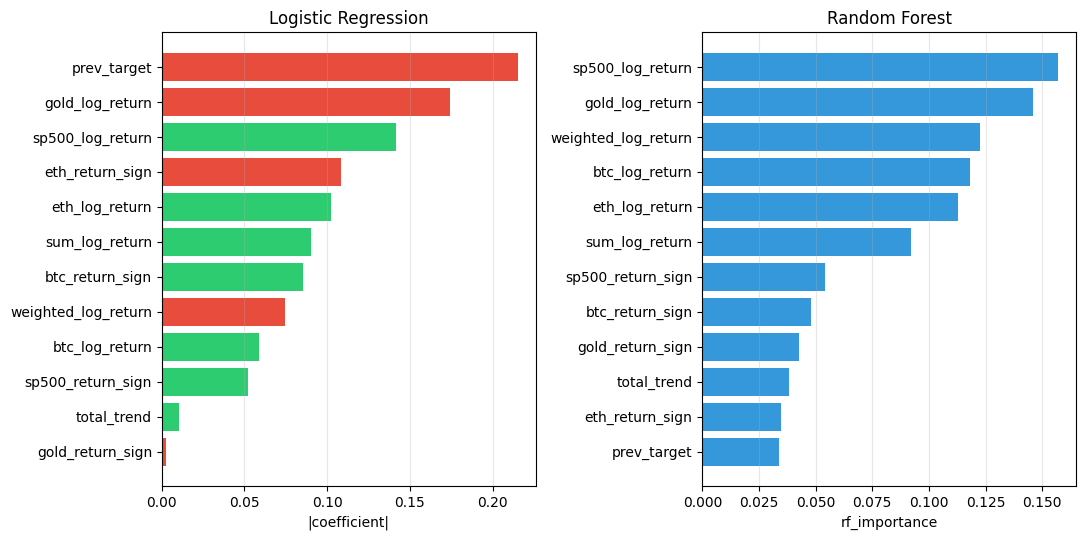

In [49]:
lr_coef = pd.Series(clf.named_steps['logreg'].coef_[0], index=FEATURE_COLS)
importance_table = pd.DataFrame({
    'logreg_coef': lr_coef,
    'rf_importance': pd.Series(rf.feature_importances_, index=FEATURE_COLS),
})

top_n = len(FEATURE_COLS)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

for ax, col, use_abs, title in [
    (axes[0], 'logreg_coef', True, 'Logistic Regression'),
    (axes[1], 'rf_importance', False, 'Random Forest'),
]:
    series = importance_table[col]
    if use_abs:
        series = series.abs().sort_values(ascending=True).tail(top_n)
        labels = importance_table.loc[series.index, 'logreg_coef']
        colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in labels]
        ax.barh(series.index, series.values, color=colors)
        ax.set_xlabel('|coefficient|')
    else:
        series = series.sort_values(ascending=True).tail(top_n)
        ax.barh(series.index, series.values, color='#3498db')
        ax.set_xlabel(col)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
plt.show()

## Results

In [50]:
def row_metrics(name, split, y, p, pred, thr):
    return {
        'model': name,
        'split': split,
        'threshold': thr,
        'accuracy': accuracy_score(y, pred),
        'balanced_accuracy': balanced_accuracy_score(y, pred),
        'roc_auc': roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
    }

results = pd.DataFrame([
    row_metrics('logreg', 'validation', y_val, lr_val_p, lr_val_pred, thr_lr),
    row_metrics('logreg', 'test', y_test, lr_test_p, lr_test_pred, thr_lr),
    row_metrics('random_forest', 'validation', y_val, rf_val_p, rf_val_pred, thr_rf),
    row_metrics('random_forest', 'test', y_test, rf_test_p, rf_test_pred, thr_rf),
    row_metrics('xgboost', 'validation', y_val, xgb_val_p, xgb_val_pred, thr_xgb),
    row_metrics('xgboost', 'test', y_test, xgb_test_p, xgb_test_pred, thr_xgb),
])


results


,model,split,threshold,accuracy,balanced_accuracy,roc_auc
0,logreg,validation,0.41,0.576923,0.562963,0.438519
1,logreg,test,0.41,0.777778,0.769231,0.703297
2,random_forest,validation,0.44,0.615385,0.604444,0.530370
3,random_forest,test,0.44,0.629630,0.620879,0.565934
4,xgboost,validation,0.50,0.519231,0.525185,0.516296
5,xgboost,test,0.50,0.592593,0.598901,0.554945


In [51]:
def baseline_accuracy(y, split_df):
    persistence = (split_df['prev_target'] == 1).astype(int)
    return [
        accuracy_score(y, np.ones(len(y))),
        accuracy_score(y, np.full(len(y), int(y_train.mean() >= 0.5))),
        accuracy_score(y, persistence),
    ]

results_benchmarks = pd.DataFrame({
    'benchmark': ['always_up', 'majority_train', 'persistence_prev_target'],
    'validation_accuracy': baseline_accuracy(y_val, val_df),
    'test_accuracy': baseline_accuracy(y_test, test_df),
})

results_benchmarks


,benchmark,validation_accuracy,test_accuracy
0,always_up,0.519231,0.518519
1,majority_train,0.519231,0.518519
2,persistence_prev_target,0.500000,0.407407


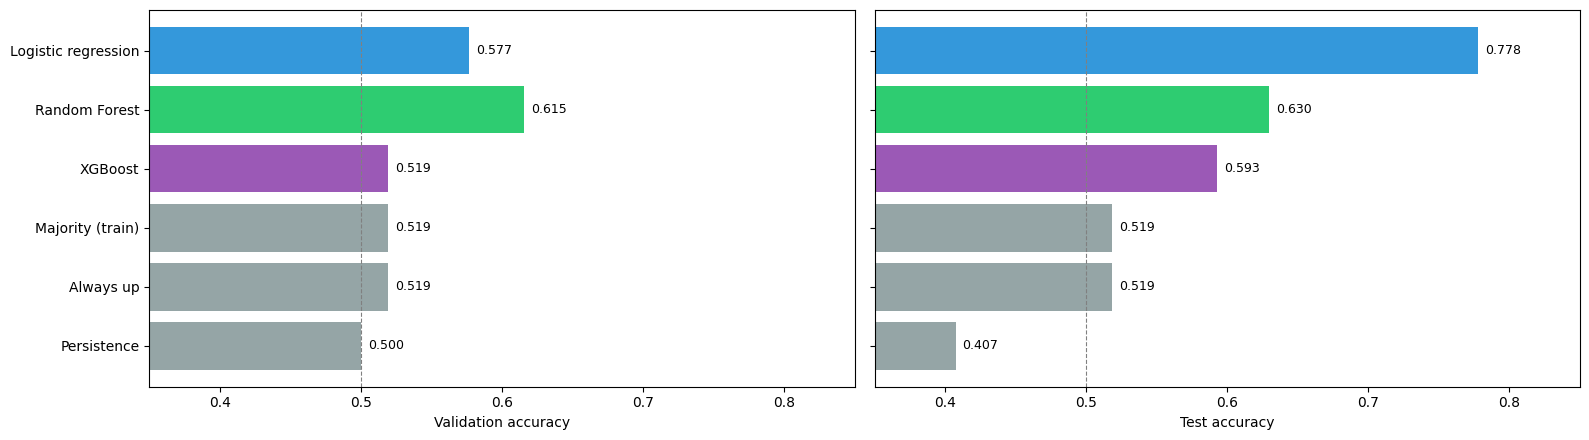

In [52]:
def build_accuracy_rows(y, split_df, logreg_pred, rf_pred, xgb_pred):
    persistence = (split_df['prev_target'] == 1).astype(int)
    return {
        'Always up': accuracy_score(y, np.ones(len(y))),
        'Majority (train)': accuracy_score(y, np.full(len(y), int(y_train.mean() >= 0.5))),
        'Persistence': accuracy_score(y, persistence),
        'Logistic regression': accuracy_score(y, logreg_pred),
        'Random Forest': accuracy_score(y, rf_pred),
        'XGBoost': accuracy_score(y, xgb_pred),
    }

def plot_accuracy_bars(ax, rows, names_order, xlabel, xlim):
    model_colors = {
        'Logistic regression': '#3498db',
        'Random Forest': '#2ecc71',
        'XGBoost': '#9b59b6',
    }
    vals = [rows[n] for n in names_order]
    colors = [model_colors.get(n, '#95a5a6') for n in names_order]
    ax.barh(names_order, vals, color=colors)
    ax.set_xlim(*xlim)
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(xlabel)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

val_rows = build_accuracy_rows(y_val, val_df, lr_val_pred, rf_val_pred, xgb_val_pred)
test_rows = build_accuracy_rows(y_test, test_df, lr_test_pred, rf_test_pred, xgb_test_pred)

names_order = sorted(
    val_rows.keys(),
    key=lambda name: max(val_rows[name], test_rows[name]),
)
xlim = (0.35, max(0.85, max(*val_rows.values(), *test_rows.values()) + 0.05))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), sharey=True)
plot_accuracy_bars(axes[0], val_rows, names_order, 'Validation accuracy', xlim)
plot_accuracy_bars(axes[1], test_rows, names_order, 'Test accuracy', xlim)
fig.tight_layout()
plt.show()